# Ridge Regression

Explore Ridge Regression to improve linear models by adding regularization to reduce noise sensitivity from correlated features. Understand how to implement ridge regression with scikit-learn, use cross-validation to tune the alpha hyperparameter, and apply these concepts to build more robust predictive models.

## Chapter Goals

- Learn about regularization in linear regression
- Learn about hyperparameter tuning using cross-validation
- Implement a cross-validated ridge regression model in scikit-learn

While ordinary least squares regression is a good way to fit a linear model onto a dataset, it relies on the fact that the dataset's features are each independent, i.e. uncorrelated. When many of the dataset features are linearly correlated, e.g. if a dataset has multiple features depicting the same price in different currencies, it makes the least squares regression model highly sensitive to noise in the data.

Because real life data tends to have noise, and will often have some linearly correlated features in the dataset, we combat this by performing regularization. For ordinary least squares regression, the goal is to find the weights (coefficients) for the linear model that minimize the sum of squared residuals:

`Σ(i=1 to n) (xi · w - yi)^2`

where each `xi` represents a data observation and `yi` is the corresponding label.

For regularization, the goal is to not only minimize the sum of squared residuals, but to do this with coefficients as small as possible. The smaller the coefficients, the less susceptible they are to random noise in the data. The most commonly used form of regularization is ridge regularization.

With ridge regularization, the goal is now to find the weights that minimize the following quantity:

`α ||w||2^2 + Σ(i=1 to n) (xi · w - yi)^2`

where `α` is a non-negative real number hyperparameter and `||w||2` represents the L2 norm of the weights. The additional

`α ||w||2^2`

is referred to as the penalty term, since it penalizes larger weight values. Larger quantities of `α` will put greater emphasis on the penalty term, forcing the model to have even smaller weight values.

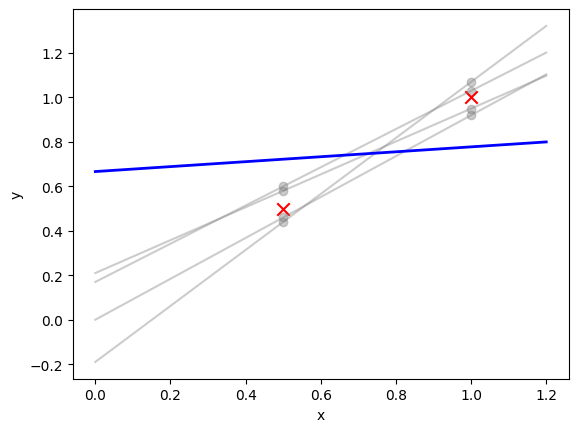

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

points = np.array([[0.5], [1.0]])
targets = np.array([0.5, 1.0])
x_plot = np.linspace(0.0, 1.2, 60).reshape(-1, 1)

noise_sets = [
    np.array([0.08, -0.05]),
    np.array([-0.06, 0.07]),
    np.array([0.10, 0.03]),
    np.array([-0.04, -0.08]),
]

for noise in noise_sets:
    noisy_targets = targets + noise

    ols = linear_model.LinearRegression()
    ols.fit(points, noisy_targets)

    plt.scatter(
        points[:, 0],
        noisy_targets,
        color="grey",
        alpha=0.4,
    )
    plt.plot(
        x_plot,
        ols.predict(x_plot),
        color="grey",
        alpha=0.4,
    )

ridge = linear_model.Ridge(alpha=1.0)
ridge.fit(points, targets)

plt.scatter(
    points[:, 0],
    targets,
    color="red",
    marker="x",
    s=80,
)
plt.plot(
    x_plot,
    ridge.predict(x_plot),
    color="blue",
    linewidth=2,
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

The plot above shows an example of ordinary least squares regression models vs. ridge regression models. The two red crosses mark the points `(0.5, 0.5)` and `(1, 1)`, and the blue lines are the regression lines for those two points. Each of the grey lines are the regression lines for the original points with added noise (which is signified by the grey points).

The ordinary least squares regression is much more susceptible to being influenced by the added noise, as there is a much larger degree of variance in the grey regression lines compared to the ridge regression.

---

## B. Choosing the best alpha

In scikit-learn, we implement ridge regression in essentially the same way we implement ordinary least squares regression. We use the `Ridge` object (part of the `linear_model` module) to implement ridge regression.

The code below fits a `Ridge` object on the pizza dataset from the previous chapter.

In [2]:
pizza_data = [
    [800, 300],
    [900, 350],
    [1000, 400],
    [1100, 450],
    [1200, 500],
]
pizza_prices = [8.0, 9.0, 10.0, 11.0, 12.0]

ridge_reg = linear_model.Ridge(alpha=1.0)
ridge_reg.fit(pizza_data, pizza_prices)

print("Coefficients:", ridge_reg.coef_)
print("Intercept:", ridge_reg.intercept_)

Coefficients: [0.00799994 0.00399997]
Intercept: 0.4000767993865004


We can specify the value of the `α` hyperparameter when initializing the `Ridge` object (the default is `1.0`). However, rather than manually choosing a value, we can use cross-validation to help us choose the optimal `α` from a list of values.

We'll discuss the specifics of cross-validation in the chapters Cross-Validation, Applying CV to Decision Trees, and Exhaustive Tuning, but for now just know that we can implement a cross-validated ridge regression using the `RidgeCV` object.

In [3]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = linear_model.RidgeCV(alphas=alphas)
ridge_cv.fit(pizza_data, pizza_prices)

print("Best alpha:", ridge_cv.alpha_)
print("R2:", ridge_cv.score(pizza_data, pizza_prices))

Best alpha: 0.01
R2: 0.9999999999999937


---

## Time to Code!

1. The coding exercise in this chapter uses the `RidgeCV` object of the `linear_model` module (imported in backend) to complete the `cv_ridge_reg` function.
2. The function will fit a ridge regression model to the input `data` and `labels`.
3. The model is cross-validated to choose the best `α` value from the input list `alphas`.
4. Set `reg` equal to `linear_model.RidgeCV` initialized with the input list, `alphas`, for the `alphas` keyword argument.
5. Call `reg.fit` with `data` and `labels` as the two input arguments.
6. Then return `reg`.

In [ ]:
def cv_ridge_reg(data, labels, alphas):
    reg = linear_model.RidgeCV(alphas=alphas)
    reg.fit(data, labels)
    return reg